In [56]:
%load_ext autoreload
%autoreload 2
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
import json
import sys
import numpy as np
# Adds the directory above the current one to the search path
sys.path.insert(0, '..') 
from training.dataset import *
class CurriculumImageDataset(Dataset):
    def __init__(self, samples, transform=None):
        """
        samples: list of tuples -> (image_path, label, difficulty_score)
        """
        self.samples = sorted(samples, key=lambda x: x[2])  # sort by difficulty
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, difficulty = self.samples[idx]
        img = Image.open(img_path).convert("RGB")
        
        if self.transform:
            img = self.transform(img)
            
        return img, label, difficulty
    
from PIL import Image
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
import yaml
with open("/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/training/config/detector/effort_vh.yaml", 'r') as f:
    config = yaml.safe_load(f)
# update with train_config
with open('/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/training/config/vhubs_train_config.yaml', 'r') as f:
    config2 = yaml.safe_load(f)
if 'label_dict' in config:
    config2['label_dict']=config['label_dict']
config.update(config2)


# Scratch Prototyping

In [2]:
def split_curriculum(dataset, splits=[0.3, 0.3, 0.4]):
    N = len(dataset)
    c1 = int(N * splits[0])
    c2 = int(N * (splits[0] + splits[1]))
    
    ds_easy = torch.utils.data.Subset(dataset, range(0, c1))
    ds_medium = torch.utils.data.Subset(dataset, range(c1, c2))
    ds_hard = torch.utils.data.Subset(dataset, range(c2, N))
    
    return [ds_easy, ds_medium, ds_hard]

In [3]:
import yaml
with open("/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/training/config/detector/effort_vh.yaml", 'r') as f:
    config = yaml.safe_load(f)
# update with train_config
with open('/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/training/config/vhubs_train_config.yaml', 'r') as f:
    config2 = yaml.safe_load(f)
if 'label_dict' in config:
    config2['label_dict']=config['label_dict']
config.update(config2)

config['train_dataset']
config['dataset_json_folder']
train_set = StratifiedSourceDataset(
        config['train_dataset'],json_folder=config['dataset_json_folder'], train=True,
        dataset_percentage=config['dataset_percentage']
)
indices_source_live_dict = train_set.indices_source_live
str_live = []
for k,v in indices_source_live_dict.items():
    str_live.append(f"{k} {len(v)}")

str_live = '|'.join(str_live)

In [13]:
print(len(train_set.live_image_paths))
print(len(train_set.deepfake_image_paths))

2161
3975


In [14]:
#train_set.__getitem__([0,0])


#return self.transform(live_image), self.transform(deepfake_image), live_label, deepfake_label

In [15]:
# Load DFD 1.0.0 prediction
dfd_json_path = "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/tools/dataset_assessor/results_att_fd3-1-0/test_200k_merged_train/dfd_1-0-0.json"
path_json = dfd_json_path
with open(path_json, 'r') as file:
    data_json = json.load(file)
#return data_json

In [16]:
#data_json_new = {k.replace("/process",""):v for k,v in data_json.items()}
data_json_new = {v["processed_path"]:v for k,v in data_json.items()}
print(len(data_json_new))

6136


In [17]:
#for path_now in train_set.live_image_paths:
#live_difficulty_scores = [data_json_new[i.replace("/processes","").replace("/face","")]['dfd_1-0-0'] if 'dfd_1-0-0' in data_json_new[i.replace("/processes","").replace("/face","")] 
#                          else -100 for i in train_set.live_image_paths]
#deepfake_difficulty_scores = [data_json_new[i.replace("/processed","").replace("-strictpose","")]['dfd_1-0-0'] if 'dfd_1-0-0' in 
#                              data_json_new[i.replace("/processed","").replace("-strictpose","")] 
#                          else -100 for i in train_set.deepfake_image_paths]
live_difficulty_scores = [data_json_new[i]['dfd_1-0-0'] if 'dfd_1-0-0' in data_json_new[i] 
                          else -100 for i in train_set.live_image_paths]
deepfake_difficulty_scores = [data_json_new[i]['dfd_1-0-0'] if 'dfd_1-0-0' in data_json_new[i] 
                              else -100 for i in train_set.deepfake_image_paths]

#data_json[train_set.live_image_paths[0]]

In [18]:
list(data_json_new.keys())[-100]

'/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/datasets/deepfake/200k_55plus/processed/fake/reswapper-strictpose/208136_verify_8148870e-d704-4811-a118-a83dcf03fd77_86ac68db-21da-4a88-97cd-a0d99f83b8e1_original_to_172214_verify_7620a1b2-4363-45a4-975f-c71f30f4ddb2_05ff5e23-0fc0-46d2-b022-c8e5d40bbc59_original.jpg'

In [19]:
live_valid_indices = [i for i in range(len(live_difficulty_scores)) if live_difficulty_scores[i] >= 0]
deepfake_valid_indices = [i for i in range(len(deepfake_difficulty_scores)) if deepfake_difficulty_scores[i] >= 0]

In [20]:
print(len(live_valid_indices))
print(len(train_set.live_image_paths))

print(len(deepfake_valid_indices))
print(len(train_set.deepfake_image_paths))

2161
2161
3975
3975


Sort by Difficulty

In [ ]:
def sort_by_difficulty(list_scores):

In [ ]:
my_list = [4, 1, 6, 2, 3]

# 1. Pair elements with their original indices
indexed_list = list(enumerate(my_list))
# indexed_list will be: [(0, 4), (1, 1), (2, 6), (3, 2), (4, 3)]

# 2. Sort the paired list based on the values
# The lambda function `lambda x: x[1]` tells sorted to use the second element of each tuple (the value) for sorting.
sorted_indexed_list = sorted(indexed_list, key=lambda x: x[1])
# sorted_indexed_list will be: [(1, 1), (3, 2), (4, 3), (0, 4), (2, 6)]

# 3. Extract the sorted values and original indices
sorted_values = [item[1] for item in sorted_indexed_list]
original_indices = [item[0] for item in sorted_indexed_list]

print(f"Original list: {my_list}")
print(f"Sorted values: {sorted_values}")
print(f"Original indices in sorted order: {original_indices}")

In [13]:
selected_elements = [train_set.live_image_paths[i] for i in live_valid_indices]
#selected_elements

In [15]:
train_data_loader = \
            torch.utils.data.DataLoader(
                dataset=train_set,
                num_workers=int(config['workers']),
                #batch_sampler= ProportionalStratifiedBatchSampler(train_set, batch_size=config['train_batchSize'],drop_last=True)
                batch_sampler= ProportionalStratifiedBatchSampler(train_set, batch_size=config['train_batchSize'])
                )

/mnt/ssd/datasets/deepfake/dataset_json/test_200k_merged_train.json 2161
/mnt/ssd/datasets/deepfake/dataset_json/test_200k_merged_train.json 3975
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_merged_train.json': 24}
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_merged_train.json': 24}


In [19]:
iter_loader = iter(train_data_loader)

In [20]:
next(iter_loader)

[tensor([[[[ 1.9011,  1.9011,  1.9011,  ..., -1.7923, -1.7923, -1.7923],
           [ 1.9011,  1.9011,  1.9011,  ..., -1.7923, -1.7923, -1.7923],
           [ 1.9011,  1.9157,  1.9157,  ..., -1.7923, -1.7923, -1.7923],
           ...,
           [-1.4565, -1.4419, -1.4273,  ..., -1.7923, -1.7923, -1.7923],
           [-1.4565, -1.4419, -1.4273,  ..., -1.7923, -1.7923, -1.7923],
           [-1.4419, -1.4273, -1.4127,  ..., -1.7923, -1.7923, -1.7923]],
 
          [[ 1.8498,  1.8498,  1.8498,  ..., -1.7521, -1.7521, -1.7521],
           [ 1.8498,  1.8498,  1.8498,  ..., -1.7521, -1.7521, -1.7521],
           [ 1.8498,  1.8648,  1.8648,  ..., -1.7521, -1.7521, -1.7521],
           ...,
           [-1.4069, -1.4069, -1.3919,  ..., -1.7521, -1.7521, -1.7521],
           [-1.4069, -1.3919, -1.3769,  ..., -1.7521, -1.7521, -1.7521],
           [-1.3919, -1.3769, -1.3619,  ..., -1.7521, -1.7521, -1.7521]],
 
          [[ 1.6766,  1.6624,  1.6624,  ..., -1.4802, -1.4802, -1.4802],
           [ 

In [24]:
train_set.deepfake_dfty_scores

[0.1111457347869873,
 0.1782580018043518,
 0.23199665546417236,
 0.9460527822375298,
 0.2779897451400757,
 0.656159520149231,
 0.02624368667602539,
 0.0019068717956542969,
 0.6458511650562286,
 0.2604641318321228,
 0.31927770376205444,
 0.008436203002929688,
 0.6308647692203522,
 0.14640384912490845,
 0.20124387741088867,
 0.00017702579498291016,
 0.49600380659103394,
 0.15597468614578247,
 0.009589910507202148,
 0.017917096614837646,
 0.12063980102539062,
 0.6057060360908508,
 0.4259777069091797,
 0.3682863712310791,
 0.7687275111675262,
 0.8541032373905182,
 0.030993878841400146,
 0.35114240646362305,
 0.7995614111423492,
 0.0014063119888305664,
 0.20525765419006348,
 0.5578531920909882,
 0.7077859342098236,
 0.44475674629211426,
 0.16516757011413574,
 0.8139984905719757,
 0.5339105725288391,
 0.5832497477531433,
 0.43505293130874634,
 0.11405104398727417,
 0.6954446732997894,
 0.9617693237960339,
 0.05636155605316162,
 0.6193499565124512,
 0.42815834283828735,
 0.40426456928253174,


In [122]:
adj_deepfake_diff_score = [1-i for i  in deepfake_difficulty_scores]

In [3]:
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

full_dataset = CurriculumImageDataset(
    samples,  # [(path, label, diff), ...]
    transform=train_tf
)

curriculum_stages = split_curriculum(full_dataset)

def make_loader(ds, batch_size=32):
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)


NameError: name 'samples' is not defined

# Analysis from StratifiedSourceDataset class

In [108]:
train_set_json = ["test_200k_merged_train","test_200k_24nov_merged_train"]
dfd_json_paths = ["/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/tools/dataset_assessor/results_att_fd3-1-0/test_200k_merged_train/dfd_1-0-0.json",
                  "/mnt/ssd/workspace/adi/repos/vh_deepfake_trainer/tools/dataset_assessor/results_att_fd3-1-0/test_200k_24nov_merged_train/dfd_1-0-0.json"]
train_set = StratifiedSourceDataset(
        [train_set_json[1]],json_folder=config['dataset_json_folder'], train=True,
        dataset_percentage=config['dataset_percentage'], dfd_json_path = dfd_json_paths[1]
    )

In [109]:
train_data_loader = \
            torch.utils.data.DataLoader(
    dataset=train_set,
    num_workers=int(config['workers']),
    #batch_sampler= ProportionalStratifiedBatchSampler(train_set, batch_size=config['train_batchSize'],drop_last=True)
    batch_sampler= ProportionalStratifiedBatchSampler(train_set, batch_size=config['train_batchSize'])
    )

sampler = ProportionalStratifiedBatchSampler(train_set, batch_size=config['train_batchSize'])

/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json 129818
/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json 347394
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json': 24}
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json': 24}
/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json 129818
/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json 347394
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json': 24}
{'/mnt/ssd/datasets/deepfake/dataset_json/test_200k_24nov_merged_train.json': 24}


In [110]:
bin_edges_live = sampler.make_bins(train_set.live_dfty_scores, n_bins=3)

live_grouped =  sampler.group_by_source_and_difficulty(
                train_set.indices_source_live,
                train_set.live_dfty_scores,
                bin_edges_live
            )

pools_source_live = {
                src: {
                    bin_id: sampler.rng.permutation(bin_indices).tolist()
                    for bin_id, bin_indices in bins.items() if bin_id in [0,1,2]
                }
                for src, bins in live_grouped.items()
            }

bin_edges_deepfake = sampler.make_bins(train_set.deepfake_dfty_scores, n_bins=3)

deepfake_grouped =  sampler.group_by_source_and_difficulty(
                train_set.indices_source_deepfake,
                train_set.deepfake_dfty_scores,
                bin_edges_deepfake
            )

pools_source_deepfake = {
                src: {
                    bin_id: sampler.rng.permutation(bin_indices).tolist()
                    for bin_id, bin_indices in bins.items() if bin_id in [0,1,2]
                }
                for src, bins in deepfake_grouped.items()
            }

#pools_source_live = {
#                src: [idx for bin_list in bins.values() for idx in bin_list]
#                for src, bins in pools_source_live.items()
#            }
#pools_source_live = {
#    src: {
#        bin_id: self.rng.permutation(bin_indices).tolist()
#        for bin_id, bin_indices in bins.items() if bin_id in self.active_bins
#    }
#    for src, bins in live_grouped.items()
#}

"""
live_grouped = self.group_by_source_and_difficulty(
    self.indices_source_live,
    self.live_dfty_scores,
    bin_edges_live
)
"""

'\nlive_grouped = self.group_by_source_and_difficulty(\n    self.indices_source_live,\n    self.live_dfty_scores,\n    bin_edges_live\n)\n'

In [111]:
dict_bin_ids ={0:[],1:[],2:[]}
for v in pools_source_deepfake.values():
    for k2,v2 in v.items():
        dict_bin_ids[k2].extend(v2)

In [112]:
def plot_multiple(image_paths, image_labels=None,nrow=1,figsize=None):
    ncol = int(np.ceil(len(image_paths)/nrow))
    #print(ncol)
    if figsize is None:
        figsize=(ncol, nrow)
        
    fig, ax = plt.subplots(nrow,ncol, figsize=figsize)

    for id_image, image_path in enumerate(image_paths):
        if os.path.exists(image_path):
            img_now = cv2.cvtColor(cv2.imread(image_path),cv2.COLOR_BGR2RGB) 
        else:
            img_now = image_path

        if nrow>1:
            ax[id_image%nrow,id_image//nrow].imshow(img_now)
            ax[id_image%nrow,id_image//nrow].axis("off")
            if image_labels:
                ax[id_image%nrow,id_image//nrow].set_title(image_labels[id_image])
        else:
            ax[id_image].imshow(img_now)
            ax[id_image].axis("off")
            if image_labels:
                ax[id_image].set_title(image_labels[id_image])
    
    plt.tight_layout()
    return fig,ax

(<Figure size 600x600 with 9 Axes>,
 array([[<Axes: title={'center': '0.65'}>,
         <Axes: title={'center': '0.81'}>,
         <Axes: title={'center': '0.55'}>],
        [<Axes: title={'center': '0.46'}>,
         <Axes: title={'center': '0.98'}>,
         <Axes: title={'center': '0.63'}>],
        [<Axes: title={'center': '0.97'}>,
         <Axes: title={'center': '0.42'}>,
         <Axes: title={'center': '0.47'}>]], dtype=object))

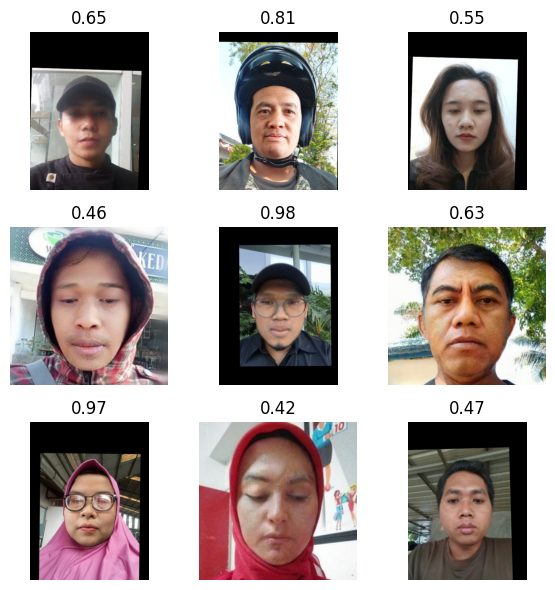

In [121]:
#print(train_set.deepfake_dfty_scores[id_now])
#Image.open(train_set.deepfake_image_paths[id_now])
sample_ids = dict_bin_ids[2][:9]
ex_img_paths = [train_set.deepfake_image_paths[id_now] for id_now in sample_ids]
ex_img_scores = [np.round(train_set.deepfake_dfty_scores[id_now],2) for id_now in sample_ids]
plot_multiple(ex_img_paths,image_labels=ex_img_scores,nrow=3,figsize=(6,6))

In [114]:
from collections import Counter

In [117]:
bin_paths = [train_set.deepfake_image_paths[id_now] for id_now in dict_bin_ids[0]]
list_method = [i.split("/")[i.split("/").index("fake")+1].split("-")[0].split("_")[0] 
               for i in bin_paths]

my_counter = Counter(list_method)
# Calculate the total sum of counts
total_counts = len(list_method) # For Python 3.10+
# total_counts = sum(my_counter.values()) # For earlier Python versions

# Create a new Counter with normalized values
normalized_counter = Counter()
for item, count in my_counter.items():
    normalized_counter[item] = np.round(count / total_counts,4)

print(normalized_counter)

Counter({'e4s': 0.3048, 'reswapper': 0.2477, 'inswapper': 0.1954, 'mobilefaceswap': 0.1582, 'blendface': 0.0939})


In [ ]:

Counter(list_method)

Counter({'e4s_20251103-strictpose': 404,
         'mobilefaceswap-strictpose': 372,
         'reswapper-strictpose': 277,
         'inswapper-strictpose': 144,
         'blendface-strictpose': 128})

#### Get Dataset Info

(<Figure size 600x600 with 16 Axes>,
 array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object))

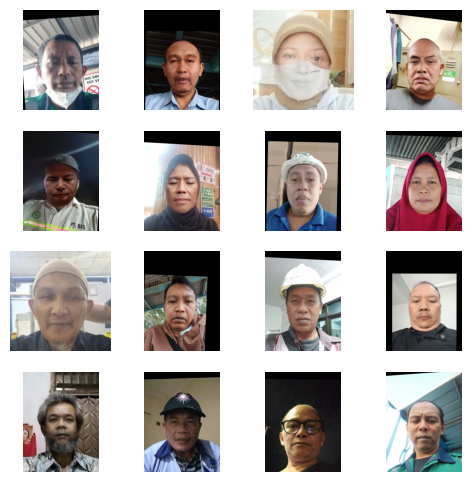

In [ ]:
with open(json_path, 'r') as f:
    data_info = json.load(f)

0.9123281091451645


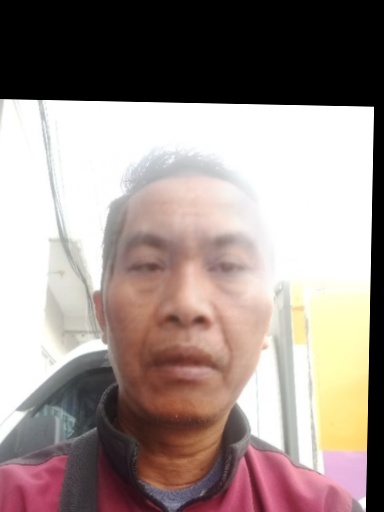

In [53]:
id_now = dict_bin_ids[2][90]
print(train_set.deepfake_dfty_scores[id_now])
Image.open(train_set.deepfake_image_paths[id_now])

### Get Bins info

Get samples

In [ ]:
train_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

full_dataset = CurriculumImageDataset(
    samples,  # [(path, label, diff), ...]
    transform=train_tf
)

curriculum_stages = split_curriculum(full_dataset)

def make_loader(ds, batch_size=32):
    return torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

In [ ]:
def progressive_curriculum(ds_easy, ds_medium, mix_ratio=0.3):
    # mix 30% of medium difficulty into easy stage
    import random
    idx_easy = list(range(len(ds_easy)))
    idx_medium = random.sample(range(len(ds_medium)), int(len(ds_medium) * mix_ratio))
    mixed_idx = idx_easy + idx_medium
    return torch.utils.data.Subset(ds_easy.dataset, mixed_idx)



In [ ]:
stage1 = progressive_curriculum(curriculum_stages[0], curriculum_stages[1], mix_ratio=0.2)
stage2 = progressive_curriculum(curriculum_stages[1], curriculum_stages[2], mix_ratio=0.3)
stage3 = curriculum_stages[2]

for name, ds in [
    ("stage1", stage1),
    ("stage2", stage2),
    ("stage3", stage3),
]:
    loader = make_loader(ds)
    train_one_stage(loader, name)
